In [2]:
!pip install matplotlib

# Inżynieria cech

Budujemy zbiór treningowy z oczyszczonych danych.

- definiujemy etykietę `Y`, czyli rezerwację po obejrzeniu oferty w oknie 24h,
- liczymy cechy recenzji widoczne w momencie sesji,
- sprawdzamy, czy te cechy różnią się dla `Y=0` i `Y=1`,

## Konstrukcja Y (etykieta)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

reviews_df = pd.read_csv("../data/interim/reviews_processed.csv")
sessions_df_clean = pd.read_csv("../data/interim/sessions_processed.csv")
listings_df = pd.read_csv("../data/interim/listings_processed.csv")

# Parse dates
reviews_df['date'] = pd.to_datetime(reviews_df['date'], errors='coerce')
reviews_df = reviews_df.dropna(subset=['date'])
sessions_df_clean['timestamp'] = pd.to_datetime(sessions_df_clean['timestamp'])

print(f"Reviews: {reviews_df.shape}")
print(f"Sessions: {sessions_df_clean.shape}")
print(f"Listings: {listings_df.shape}")

Reviews: (46935, 9)
Sessions: (470445, 4)
Listings: (3646, 8)


In [ ]:
# Filter to relevant session types
sessions_filtered = sessions_df_clean[sessions_df_clean['action'].isin(['view_listing', 'book_listing'])].copy()
sessions_filtered = sessions_filtered.drop_duplicates()

# Separate views from bookings
views_df = sessions_filtered[sessions_filtered["action"] ==
                             "view_listing"][['user_id', 'timestamp', 'listing_id']].copy()
bookings_df = sessions_filtered[sessions_filtered["action"] ==
                                "book_listing"][['user_id', 'listing_id', 'timestamp']].copy()
bookings_df = bookings_df.rename(columns={'timestamp': 'booking_timestamp'})

# Forward point-in-time join: for each view, find if a booking happened within 24h
views_df = views_df.sort_values('timestamp')
bookings_df = bookings_df.sort_values('booking_timestamp')
merged_df = pd.merge_asof(
    left=views_df,
    right=bookings_df,
    left_on='timestamp',
    right_on='booking_timestamp',
    by=['user_id', 'listing_id'],
    direction='forward',
    tolerance=pd.Timedelta(hours=24)
)

# Y=1 if booking timestamp present (offer was reserved)
merged_df['Y'] = merged_df['booking_timestamp'].notna().astype(int)
training_data = merged_df.drop(columns=['booking_timestamp']).reset_index(drop=True)
print(f"Training data: {training_data.shape}")

Training data: (431281, 4)


In [5]:
print(len(training_data[training_data["Y"] == 1]))
print(len(training_data[training_data["Y"] == 0]))

15546
415735


## Konstrukcja cech (X)

Dla każdego `view_listing` liczymy cechy dostępne w momencie sesji. Recenzję z dnia `D` uznajemy za widoczną dopiero od `D+1`.

Cechy z recenzji:

| Cecha                     | Opis                                                        |
| ------------------------- | ----------------------------------------------------------- |
| `days_since_last_review`  | dni od ostatniej widocznej recenzji; `-1` gdy brak recenzji |
| `reviews_in_last_90_days` | liczba recenzji z ostatnich 90 dni                          |
| `recent_review_scores_*`  | średnie sentymenty z ostatnich 90 dni                       |
| `alltime_review_count`    | liczba wszystkich widocznych recenzji                       |
| `alltime_review_scores_*` | średnie sentymenty ze wszystkich widocznych recenzji        |

Na końcu dokładamy cechy z `Listings`.


In [6]:
sentiment_cols = [c for c in reviews_df.columns if c.startswith('review_scores_')]

# D+1
reviews_df['visible_date'] = reviews_df['date'] + pd.Timedelta(days=1)

# FEATURE: days_since_last_review
# merge_asof backward: find the latest review visible before each session
td_sorted = training_data[['listing_id', 'timestamp']].copy()
td_sorted['_orig_idx'] = td_sorted.index
td_sorted = td_sorted.sort_values('timestamp')

rv_for_asof = reviews_df[['listing_id', 'visible_date', 'date']].sort_values('visible_date')

asof_result = pd.merge_asof(
    td_sorted,
    rv_for_asof.rename(columns={'visible_date': '_vis_ts', 'date': '_review_date'}),
    left_on='timestamp',
    right_on='_vis_ts',
    by='listing_id',
    direction='backward'
)
asof_result['days_since_last_review'] = (asof_result['timestamp'] - asof_result['_review_date']).dt.days

# NaN = listing has no reviews at all → fill with -1
training_data['days_since_last_review'] = (
    asof_result.set_index('_orig_idx')['days_since_last_review'].fillna(-1).astype(int)
)

pct_no_review = (training_data['days_since_last_review'] == -1).mean() * 100
print(f"days_since_last_review: {pct_no_review:.1f}% have no reviews (filled with -1)")
print(training_data['days_since_last_review'].describe())

days_since_last_review: 73.0% have no reviews (filled with -1)
count    431281.000000
mean        158.668610
std         445.360041
min          -1.000000
25%          -1.000000
50%          -1.000000
75%          21.000000
max        4271.000000
Name: days_since_last_review, dtype: float64


In [ ]:
# FEATURES: 90-day window + all-time historical features
td_slim = training_data[['listing_id', 'timestamp']].copy()
td_slim['_td_idx'] = td_slim.index

rv_slim = reviews_df[['listing_id', 'visible_date'] + sentiment_cols].copy()

merged = td_slim.merge(rv_slim, on='listing_id', how='inner')

# Keep only reviews visible BEFORE the session
merged = merged[merged['visible_date'] <= merged['timestamp']]
merged['days_ago'] = (merged['timestamp'] - merged['visible_date']).dt.days
print(f"Total visible review-session pairs: {len(merged):,}")

# All-time features
alltime_agg = {col: 'mean' for col in sentiment_cols}
alltime_agg['visible_date'] = 'count'
alltime = merged.groupby('_td_idx').agg(alltime_agg)
alltime = alltime.rename(columns={'visible_date': 'alltime_review_count'})
alltime = alltime.rename(columns={c: f'alltime_{c}' for c in sentiment_cols})

# 90-day window features
recent = merged[merged['days_ago'] <= 90]
recent_agg = {col: 'mean' for col in sentiment_cols}
recent_agg['visible_date'] = 'count'
recent_feats = recent.groupby('_td_idx').agg(recent_agg)
recent_feats = recent_feats.rename(columns={'visible_date': 'reviews_in_last_90_days'})
recent_feats = recent_feats.rename(columns={c: f'recent_{c}' for c in sentiment_cols})

# Join all features back
training_data = training_data.join(alltime)
training_data = training_data.join(recent_feats)

# Fill NaN (sessions with no reviews at all)
training_data['alltime_review_count'] = training_data['alltime_review_count'].fillna(0).astype(int)
training_data['reviews_in_last_90_days'] = training_data['reviews_in_last_90_days'].fillna(0).astype(int)
for c in sentiment_cols:
    training_data[f'alltime_{c}'] = training_data[f'alltime_{c}'].fillna(0.0)
    training_data[f'recent_{c}'] = training_data[f'recent_{c}'].fillna(0.0)

pct_90d = (training_data['reviews_in_last_90_days'] > 0).mean() * 100
pct_all = (training_data['alltime_review_count'] > 0).mean() * 100
print(f"\nCoverage: {pct_90d:.1f}% have reviews in 90-day window, {pct_all:.1f}% have any review ever")
print(f"Features computed. Shape: {training_data.shape}")
training_data.head()

Total visible review-session pairs: 504,007

Coverage: 6.3% have reviews in 90-day window, 27.0% have any review ever
Features computed. Shape: (431281, 21)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,alltime_review_scores_rating,alltime_review_count,recent_review_scores_cleanliness,recent_review_scores_location,recent_review_scores_communication,recent_review_scores_checkin,recent_review_scores_value,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Inner join: keep only sessions for listings we have data for
rows_before = len(training_data)
training_data['listing_id'] = training_data['listing_id'].astype('Int64')
listings_df['listing_id'] = listings_df['listing_id'].astype('Int64')
training_data = training_data.merge(listings_df, on='listing_id', how='inner')
print(
    f"Rows before join: {rows_before:,} → after inner join: {len(training_data):,} ({100*len(training_data)/rows_before:.1f}% kept)")

# Replace remaining nulls in numeric listing columns with median
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'price']
for col in num_cols:
    n_null = training_data[col].isnull().sum()
    if n_null > 0:
        training_data[col] = training_data[col].fillna(training_data[col].median())
        print(f"Imputed {n_null} nulls in {col} with median")

# Fill null categories with "Unknown"
cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed']
for col in cat_cols:
    training_data[col] = training_data[col].fillna('Unknown')

print(f"\nFinal training data: {training_data.shape}")
print(f"Nulls remaining: {training_data.isnull().sum().sum()}")
print("\nCategorical cardinalities:")
for col in cat_cols:
    print(f"  {col}: {training_data[col].nunique()} unique values")
training_data.head()

Rows before join: 431,281 → after inner join: 317,277 (73.6% kept)
Imputed 61553 nulls in accommodates with median
Imputed 66307 nulls in bathrooms with median
Imputed 73392 nulls in bedrooms with median
Imputed 164782 nulls in price with median

Final training data: (317277, 28)
Nulls remaining: 0

Categorical cardinalities:
  property_type: 9 unique values
  room_type: 5 unique values
  neighbourhood_cleansed: 12 unique values


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,812.0,Bispebjerg
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,3.0,1359.0,Vesterbro-Kongens Enghave
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,1.0,1200.0,Indre By
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,5.0,1.0,3.0,2821.0,Unknown
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,629.0,Vesterbro-Kongens Enghave


## Rozkład Y

Sprawdzamy, ile jest rezerwacji, a ile przypadków bez rezerwacji. Od tego zależy wybór metryk.


Class 0 (no booking): 314,973
Class 1 (booking):    2,304
Imbalance ratio Y=1/Y=0: 0.0073


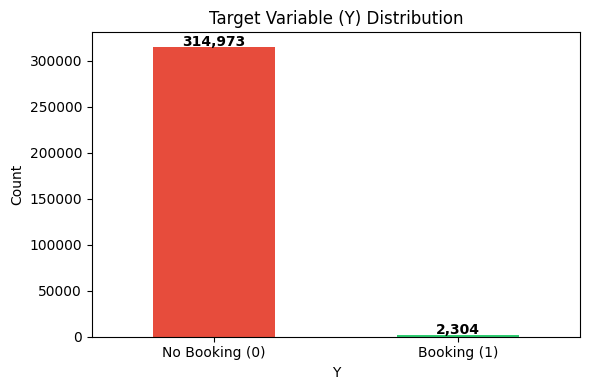

In [9]:
counts = training_data['Y'].value_counts().sort_index()
print(f"Class 0 (no booking): {counts.get(0, 0):,}")
print(f"Class 1 (booking):    {counts.get(1, 0):,}")
print(f"Imbalance ratio Y=1/Y=0: {counts.get(1, 0) / counts.get(0, 1):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['No Booking (0)', 'Booking (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Variable (Y) Distribution')
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Rozkłady wygenerowanych cech

Sprawdzamy, dla ilu wierszy danych model ma realne informacje z recenzji, a dla ilu widzi tylko brak recenzji (`-1` lub `0`).


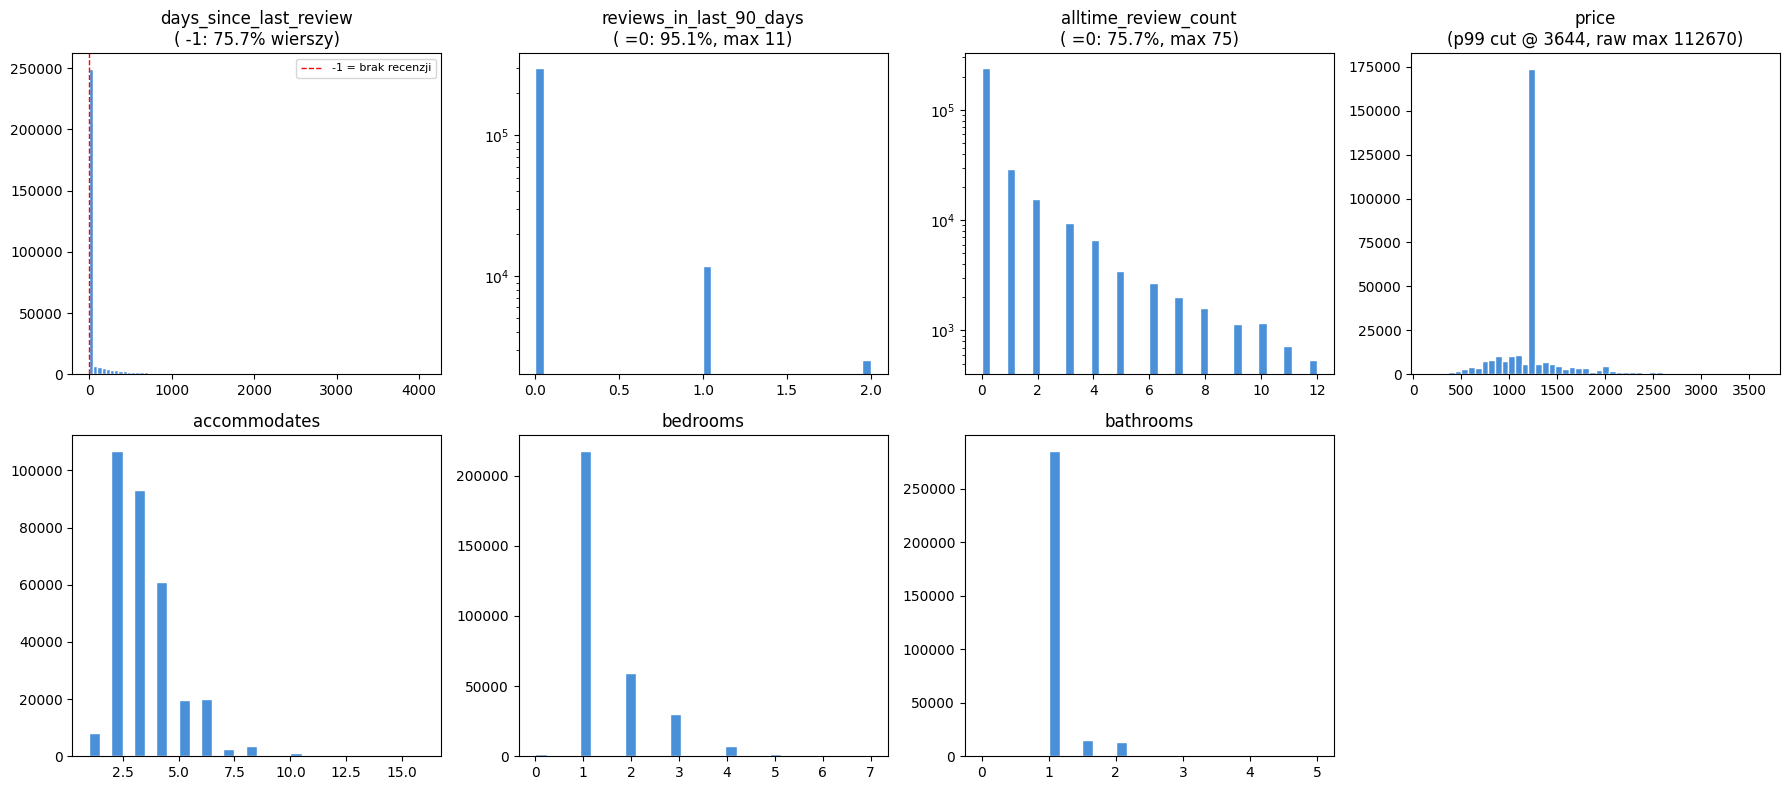

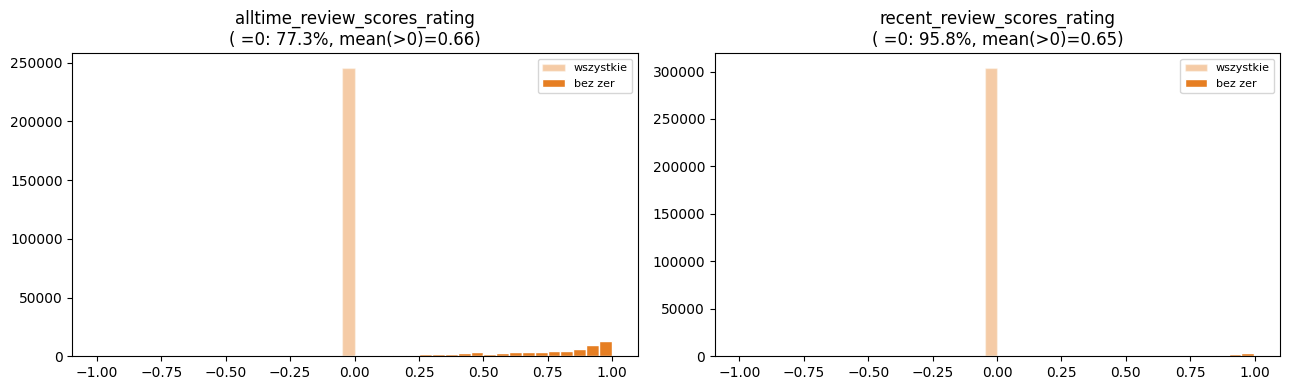

In [ ]:
numeric_feats = [
    'days_since_last_review', 'reviews_in_last_90_days', 'alltime_review_count',
    'price', 'accommodates', 'bedrooms', 'bathrooms'
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, f in enumerate(numeric_feats):
    ax = axes[i]
    vals = training_data[f].to_numpy()
    # clip outliers
    if f == 'price':
        clip = np.percentile(vals, 99)
        ax.hist(vals[vals <= clip], bins=50, color='#4a90d9', edgecolor='white')
        ax.set_title(f"{f}\n(p99 cut @ {clip:.0f}, raw max {vals.max():.0f})")
    elif f == 'days_since_last_review':
        ax.hist(vals, bins=80, color='#4a90d9', edgecolor='white')
        ax.axvline(-1, color='red', linestyle='--', linewidth=1, label='-1 = brak recenzji')
        ax.set_title(f"{f}\n( -1: {(vals == -1).mean()*100:.1f}% wierszy)")
        ax.legend(fontsize=8)
    elif f in ('reviews_in_last_90_days', 'alltime_review_count'):
        clip = np.percentile(vals, 99)
        ax.hist(vals[vals <= clip], bins=40, color='#4a90d9', edgecolor='white')
        ax.set_yscale('log')
        ax.set_title(f"{f}\n( =0: {(vals == 0).mean()*100:.1f}%, max {vals.max()})")
    else:
        ax.hist(vals, bins=30, color='#4a90d9', edgecolor='white')
        ax.set_title(f)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

# rating jako reprezentatywny sentyment
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['alltime_review_scores_rating', 'recent_review_scores_rating']):
    v = training_data[col].to_numpy()
    nz = v[v != 0]
    ax.hist(v, bins=40, color='#e67e22', edgecolor='white', alpha=0.4, label='wszystkie')
    ax.hist(nz, bins=40, color='#e67e22', edgecolor='white', label='bez zer')
    ax.set_title(f"{col}\n( =0: {(v == 0).mean()*100:.1f}%, mean(>0)={nz.mean():.2f})")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Obserwacje:

- `days_since_last_review = -1` dla ok. 73% wierszy, czyli większość sesji nie ma widocznych recenzji.
- `reviews_in_last_90_days = 0` dla ok. 94% wierszy.
- `price` ma pojedyncze bardzo wysokie wartości.
- Sentymenty są często zerowe, bo wiele ofert nie ma recenzji w danym oknie czasowym.


## Czy cechy różnią się dla Y=0 i Y=1?

Porównujemy podstawowe statystyki dla rezerwacji i braku rezerwacji. Dodatkowo liczymy ROC-AUC dla pojedynczych cech, żeby zobaczyć, czy same w sobie niosą informację.


In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

key_feats = [
    'days_since_last_review', 'reviews_in_last_90_days', 'alltime_review_count',
    'alltime_review_scores_rating', 'recent_review_scores_rating',
    'alltime_review_scores_location', 'alltime_review_scores_communication',
    'price', 'accommodates', 'bedrooms',
]

rows = []
for f in key_feats:
    g0 = training_data.loc[training_data['Y'] == 0, f]
    g1 = training_data.loc[training_data['Y'] == 1, f]
    auc = roc_auc_score(training_data['Y'], training_data[f])
    rows.append({
        'feature': f,
        'Y=0 mean': g0.mean(),
        'Y=1 mean': g1.mean(),
        'ratio (1/0)': (g1.mean() / g0.mean()) if g0.mean() not in (0, np.nan) else float('nan'),
        'AUC': auc,
        '|AUC-0.5|': abs(auc - 0.5),
    })
comp = pd.DataFrame(rows).sort_values('|AUC-0.5|', ascending=False)
print("Porównanie Y=0 vs Y=1 i ROC-AUC (sort: |AUC-0.5|)")
print(comp.to_string(index=False, float_format=lambda x: f'{x:8.4f}' if isinstance(x, float) else str(x)))

Porównanie Y=0 vs Y=1 i ROC-AUC (sort: |AUC-0.5|)
                            feature  Y=0 mean  Y=1 mean  ratio (1/0)      AUC  |AUC-0.5|
               alltime_review_count    0.8489    4.0247       4.7412   0.6807     0.1807
       alltime_review_scores_rating    0.1492    0.3623       2.4282   0.6483     0.1483
     alltime_review_scores_location    0.0700    0.1674       2.3924   0.6364     0.1364
             days_since_last_review  156.1471  153.8060       0.9850   0.6350     0.1350
alltime_review_scores_communication    0.0533    0.1288       2.4148   0.6227     0.1227
            reviews_in_last_90_days    0.0625    0.4414       7.0578   0.6042     0.1042
        recent_review_scores_rating    0.0267    0.1543       5.7827   0.5862     0.0862
                              price 1331.8151 1478.0933       1.1098   0.4817     0.0183
                           bedrooms    1.4616    1.4132       0.9669   0.4884     0.0116
                       accommodates    3.2537    3.2257     

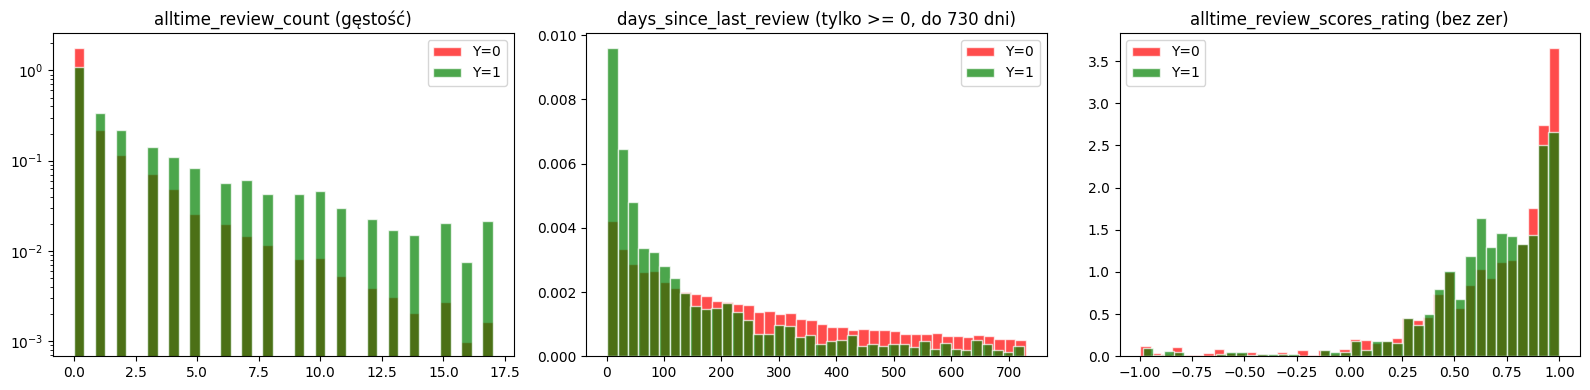

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. alltime_review_count - log-skali, przez długi ogon
ax = axes[0]
for y, color, label in [(0, 'red', 'Y=0'), (1, 'green', 'Y=1')]:
    v = training_data.loc[training_data['Y'] == y, 'alltime_review_count']
    v_clip = v[v <= np.percentile(training_data['alltime_review_count'], 99.5)]
    ax.hist(v_clip, bins=40, color=color, edgecolor='white', alpha=0.7, label=label, density=True)
ax.set_yscale('log')
ax.set_title('alltime_review_count (gęstość)')
ax.legend()

# 2. days_since_last_review
ax = axes[1]
for y, color, label in [(0, 'red', 'Y=0'), (1, 'green', 'Y=1')]:
    v = training_data.loc[training_data['Y'] == y, 'days_since_last_review']
    v_pos = v[(v >= 0) & (v <= 730)]
    ax.hist(v_pos, bins=40, color=color, edgecolor='white', alpha=0.7, label=label, density=True)
ax.set_title('days_since_last_review (tylko >= 0, do 730 dni)')
ax.legend()

# 3. alltime_review_scores_rating
ax = axes[2]
for y, color, label in [(0, 'red', 'Y=0'), (1, 'green', 'Y=1')]:
    v = training_data.loc[training_data['Y'] == y, 'alltime_review_scores_rating']
    nz = v[v != 0]
    ax.hist(nz, bins=40, color=color, edgecolor='white', alpha=0.7, label=label, density=True)
ax.set_title('alltime_review_scores_rating (bez zer)')
ax.legend()

plt.tight_layout()
plt.show()

Wyniki:

- `alltime_review_count` ma najwyższy pojedynczy AUC, ok. 0.68.
- `alltime_review_scores_rating` ma AUC ok. 0.65.
- `days_since_last_review` też różnicuje klasy, choć trzeba pamiętać, że `-1` oznacza brak recenzji.
- Sama cena, liczba osób czy sypialni mają AUC blisko 0.5.

Wniosek: w cechach recenzji jest sygnał, ale nie jest bardzo silny. Powinno to wystarczyć dla prostego modelu.


## Model bazowy

Porównujemy model naiwny z prostą regresją logistyczną. To daje punkt odniesienia dla późniejszych modeli.

Używamy ROC-AUC i Average Precision, bo rezerwacji jest bardzo mało względem przypadków bez rezerwacji.


In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

drop_cols = ['user_id', 'timestamp', 'listing_id', 'Y']
X = training_data.drop(columns=drop_cols)
y = training_data['Y'].astype(int)

cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed']
num_cols = [c for c in X.columns if c not in cat_cols]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(X_tr[cat_cols])


def to_matrix(df):
    return np.hstack([df[num_cols].to_numpy(dtype=float), enc.transform(df[cat_cols])])


Xtr = to_matrix(X_tr)
Xte = to_matrix(X_te)
scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xte_s = scaler.transform(Xte)

baseline_ap = y_te.mean()


def score(name, proba):
    auc = roc_auc_score(y_te, proba) if len(set(proba)) > 1 else 0.5
    ap = average_precision_score(y_te, proba)
    print(f"  {name:36s}  ROC-AUC={auc:.4f}   AP={ap:.4f}  ({ap/baseline_ap:.1f}× baseline)")


print(f"Baseline AP (= częstość klasy pozytywnej w teście): {baseline_ap:.4f}\n")

print("Modele naiwne (Dummy):")
for strat in ['stratified', 'most_frequent', 'prior', 'uniform']:
    d = DummyClassifier(strategy=strat, random_state=42).fit(Xtr, y_tr)
    try:
        proba = d.predict_proba(Xte)[:, 1]
    except Exception:
        proba = d.predict(Xte).astype(float)
    score(f"Dummy({strat})", proba)

print("\nLogisticRegression:")
lr = LogisticRegression(class_weight='balanced', max_iter=500, solver='lbfgs').fit(Xtr_s, y_tr)
score("LogReg(balanced) na wszystkich cechach", lr.predict_proba(Xte_s)[:, 1])

# wariant tylko na cechach recenzyjnych - sprawdza, czy statyczne cechy listingu dokładają cokolwiek
review_idx = [i for i, c in enumerate(num_cols)
              if 'review' in c or 'days_since_last_review' in c or 'reviews_in_last_90_days' in c]
review_idx_full = list(range(len(num_cols)))
review_only_idx = [i for i, c in enumerate(num_cols) if 'review' in c or c == 'days_since_last_review']
Xtr_rev = scaler.fit_transform(X_tr[[num_cols[i] for i in review_only_idx]].to_numpy(dtype=float))
Xte_rev = scaler.transform(X_te[[num_cols[i] for i in review_only_idx]].to_numpy(dtype=float))
lr2 = LogisticRegression(class_weight='balanced', max_iter=500, solver='lbfgs').fit(Xtr_rev, y_tr)
score("LogReg(balanced) - tylko cechy z recenzji", lr2.predict_proba(Xte_rev)[:, 1])

Baseline AP (= częstość klasy pozytywnej w teście): 0.0073

Modele naiwne (Dummy):
  Dummy(stratified)                     ROC-AUC=0.4985   AP=0.0073  (1.0× baseline)
  Dummy(most_frequent)                  ROC-AUC=0.5000   AP=0.0073  (1.0× baseline)
  Dummy(prior)                          ROC-AUC=0.5000   AP=0.0073  (1.0× baseline)
  Dummy(uniform)                        ROC-AUC=0.5000   AP=0.0073  (1.0× baseline)

LogisticRegression:
  LogReg(balanced) na wszystkich cechach  ROC-AUC=0.6811   AP=0.0256  (3.5× baseline)
  LogReg(balanced) - tylko cechy z recenzji  ROC-AUC=0.6501   AP=0.0230  (3.2× baseline)


Wyniki:

- Model naiwny ma ROC-AUC ok. 0.50 i AP ok. 0.0073.
- Regresja logistyczna ma ROC-AUC ok. 0.68 i AP ok. 0.026.

To jest nasz punkt odniesienia: kolejne modele powinny być lepsze przynajmniej od regresji logistycznej, a nie tylko od modelu naiwnego.


## Próbka inferencyjna

Bierzemy ostatnie 30 dni jako przykładowe dane, dla których model miałby później wygenerować predykcje. Usuwamy `Y`, bo przy prawdziwej predykcji tej informacji jeszcze nie ma.


In [14]:
# Generate inference sample from the most recent 30 days of data
latest_date = training_data['timestamp'].max()
cutoff = latest_date - pd.Timedelta(days=30)

inference_sample = training_data[training_data['timestamp'] >= cutoff].copy()
inference_sample = inference_sample.drop(columns=['Y'])  # Target not visible

print(f"Inference sample: {inference_sample.shape} (last 30 days of data)")
inference_sample.head()

Inference sample: (508, 27) (last 30 days of data)


,user_id,timestamp,listing_id,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,alltime_review_scores_accuracy,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
316769,40137464,2025-08-09 20:35:12.006548,955594135974379648,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Unknown,Unknown,2.0,1.0,1.0,1200.0,Vesterbro-Kongens Enghave
316770,360554333,2025-08-09 21:05:24.508420,1244147958257977344,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Unknown,Entire home/apt,2.0,1.0,1.0,1035.0,sterbro
316771,179697571,2025-08-09 21:25:27.516388,1397753249851294464,5,0.0,0.6324,0.3592,0.0,0.0,0.32945,...,0.32945,0.9373,2,Private room in condo,Private room,1.0,1.0,1.0,1200.0,Nrrebro
316772,360554333,2025-08-09 21:46:06.508420,1502922937698947584,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,2143.0,Unknown
316773,179697571,2025-08-09 22:20:52.516388,1434115704779021312,-1,0.0,0.0000,0.0000,0.0,0.0,0.00000,...,0.00000,0.0000,0,Entire rental unit,Entire home/apt,3.0,2.0,1.0,2050.0,Unknown


In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)

training_data.to_csv("../data/processed/training_data.csv", index=False)
inference_sample.to_csv("../data/processed/inference_sample.csv", index=False)
print(
    f"Saved training_data.csv ({training_data.shape}) and inference_sample.csv ({inference_sample.shape}) to data/processed/")

Saved training_data.csv ((317277, 28)) and inference_sample.csv ((508, 27)) to data/processed/


## Wnioski

- Zbiór treningowy ma 317 277 wierszy i 28 kolumn.
- Klasa pozytywna to ok. 0.73%, więc problem jest mocno niezbalansowany.
- Najwięcej sygnału widać w liczbie recenzji i średnim sentymencie historycznym.
- Model naiwny daje ROC-AUC ok. 0.50, a prosta regresja logistyczna ok. 0.68.
- Dane mają ograniczenia: wiele sesji nie ma żadnych widocznych recenzji, a część sentymentów może być zaszumiona przez nieangielskie komentarze.
